# HIFtool PSRT — HARVARD Dataset Evaluation

In [13]:
# Downgrade PyTorch for P100 compatibility
!pip install torch==2.4.1 torchvision==0.19.1 --index-url https://download.pytorch.org/whl/cu121 -q
!pip install imgvision einops scipy timm --no-deps -q
!pip install timm -q
!git clone https://github.com/Nikesh0907/HIFtool.git /kaggle/working/HIFtool 2>/dev/null || true

In [14]:
import os, sys, glob, argparse, time
import numpy as np, torch, torch.nn as nn
import scipy.io as sio, torch.utils.data as data
import matplotlib.pyplot as plt, imgvision as iv

HIFTOOL_DIR = '/kaggle/working/HIFtool'
sys.path.insert(0, HIFTOOL_DIR)

# Device with CUDA smoke test
device = 'cpu'
if torch.cuda.is_available():
    try:
        x = torch.randn(1,1,4,4).cuda()
        torch.nn.functional.interpolate(x, scale_factor=2, mode='bilinear')
        device = 'cuda'
        print(f'GPU OK: {torch.cuda.get_device_name()}')
    except Exception as e:
        print(f'GPU broken, using CPU')
print(f'Device: {device}  |  PyTorch: {torch.__version__}')

DATA_ROOT = '/kaggle/input/datasets/nikeshreddypatlolla/harvard-hsi-2/Data'
if not os.path.exists(DATA_ROOT):
    DATA_ROOT = '/kaggle/input/harvard-hsi-2/Data'
if not os.path.exists(DATA_ROOT):
    # Try searching for any folder containing 'harvard' and 'Data'
    possible_roots = glob.glob('/kaggle/input/**/Data', recursive=True)
    for root in possible_roots:
        if 'harvard' in root.lower():
            DATA_ROOT = root
            break
possible_ckpts = sorted(glob.glob('/kaggle/input/models/nikeshreddypatlolla/model-psrt/**/*.pth', recursive=True))
if not possible_ckpts:
    possible_ckpts = sorted(glob.glob('/kaggle/input/**/*.pth', recursive=True))
if not possible_ckpts:
    print('ERROR: No checkpoint (.pth) found!')
    CKPT_PATH = None
else:
    CKPT_PATH = possible_ckpts[0]

all_mat = sorted(glob.glob(os.path.join(DATA_ROOT, '**', '*.mat'), recursive=True))
test_mats = [f for f in all_mat if '/Test/HSI/' in f]
if not test_mats:
    test_mats = [f for f in all_mat if '/Test/' in f or '/test/' in f]
if not test_mats:
    test_mats = all_mat
if len(test_mats) == 0:
    print(f'ERROR: No .mat files found in {DATA_ROOT}')
    print('Please ensure the Harvard dataset is correctly attached to the notebook.')
else:
    print(f'Test HSI files: {len(test_mats)}')
print(f'Checkpoint: {CKPT_PATH}')

GPU OK: Tesla T4
Device: cuda  |  PyTorch: 2.4.1+cu121
Test HSI files: 20
Checkpoint: /kaggle/input/models/nikeshreddypatlolla/model-psrt/pytorch/default/1/1750.pth


In [15]:
def load_hsi(filepath):
    import scipy.io as sio
    import numpy as np
    try:
        d = sio.loadmat(filepath)
    except NotImplementedError:
        import h5py
        with h5py.File(filepath, 'r') as f:
            d = {k: np.array(f[k]) for k in f.keys()}
    
    # Try common keys for spectral data
    if 'ref' in d: gt = d['ref'].astype(np.float64)
    elif 'hsi' in d: gt = d['hsi'].astype(np.float64)
    elif 'HSI' in d: gt = d['HSI'].astype(np.float64)
    elif 'data' in d: gt = d['data'].astype(np.float64)
    else:
        # Fallback: take the largest array that's not metadata
        arrays = {k: v for k, v in d.items() if not k.startswith('__') and hasattr(v, 'shape') and v.ndim >= 2}
        if not arrays: return None
        gt = max(arrays.values(), key=lambda v: v.size).astype(np.float64)
        
    # Handle dimension order (H, W, C)
    if gt.ndim == 3:
        if gt.shape[0] <= 31 and gt.shape[2] > 31: # Likely (C, H, W)
            gt = gt.transpose(1, 2, 0)
        elif gt.shape[1] <= 31 and gt.shape[0] > 31: # Likely (H, C, W)
            gt = gt.transpose(0, 2, 1)
            
    if gt.max() > 1.0: gt = gt / gt.max()
    return gt


## Build PSRT model

In [16]:
from Networks.PSRT.net import PSRTnet

# PSRT config — bypass argparse
opt = argparse.Namespace(
    sf=32,
    patch_size=32 * 5,   # 160 — default from config.py
    msi_channel=3,       # CAVE uses 3-channel RGB
    hsi_channel=31,      # CAVE has 31 spectral bands
    n_bands=31,
    clip_max_norm=10,
    lr=1e-4,
)

model = PSRTnet(opt).to(device)
print(f'PSRT params: {sum(p.numel() for p in model.parameters()):,}')

# Load weights
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
sd = ckpt.get('net', ckpt) if isinstance(ckpt, dict) else ckpt
sd = {k.replace('module.', ''): v for k, v in sd.items()}
m, u = model.load_state_dict(sd, strict=False)
print(f'Loaded | missing:{len(m)} unexpected:{len(u)}')
if m: print(f'  Missing keys: {m[:5]}')
if u: print(f'  Unexpected keys: {u[:5]}')
model.eval()
print('PSRT ready ✓')

PSRT params: 247,455
Loaded | missing:0 unexpected:0
PSRT ready ✓


## Prepare data

In [17]:
out_dir = './results/PSRT_harvard'
os.makedirs(out_dir, exist_ok=True)
def getGk(ksize, sigma):
    x = torch.arange(-(ksize-1)//2, (ksize-1)//2+1)
    k = torch.exp(-0.5*(x/sigma)**2); k /= k.sum()
    return k.view(-1, 1).float()

class SpaDown(nn.Module):
    def __init__(self, sf):
        super().__init__()
        k = getGk(sf, sf/1.5); k = k @ k.T
        self.down = nn.Conv2d(1, 1, sf, sf, bias=False)
        self.down.weight.data[0, 0] = k
        self.down.requires_grad_(False)
    def forward(self, x):
        # x: (B, C, H, W) -> transpose(1, 0) makes it (C, B, H, W)
        # down processes B channels if B=1
        return self.down(x.transpose(1, 0)).transpose(1, 0)

SRF = np.load(os.path.join(HIFTOOL_DIR, 'Dataloader_tool', 'srflib', 'NikonD700.npy'))
print(f'SRF: {SRF.shape}')

class HarvardDataset(data.Dataset):
    def __init__(self, mat_paths, sf, srf):
        self.HR, self.LR, self.MSI, self.names = [], [], [], []
        sp = SpaDown(sf)
        for fp in mat_paths:
            gt = load_hsi(fp)
            if gt is None: continue
            gt31 = gt[:, :, :srf.shape[0]]
            h, w = gt31.shape[:2]
            # Crop to be divisible by sf
            gt31 = gt31[:h - (h % sf), :w - (w % sf), :]
            # Downsample using SpaDown
            hr_tensor = torch.tensor(gt31).permute(2, 0, 1).unsqueeze(0).float()
            lr_tensor = sp(hr_tensor)
            lr = lr_tensor[0].permute(1, 2, 0).numpy()
            msi = gt31 @ srf
            self.HR.append(gt31); self.LR.append(lr); self.MSI.append(msi)
            self.names.append(os.path.splitext(os.path.basename(fp))[0])
            print(f'  {self.names[-1]}: {gt31.shape} -> LR {lr.shape}')
            
    def __getitem__(self, i):
        return (torch.FloatTensor(self.HR[i].transpose(2,0,1)),
                torch.FloatTensor(self.LR[i].transpose(2,0,1)),
                torch.FloatTensor(self.MSI[i].transpose(2,0,1)))
    def __len__(self): return len(self.HR)

print(f'Building dataset from {len(test_mats)} HSI files...')
ds = HarvardDataset(test_mats, opt.sf, SRF)
loader = data.DataLoader(ds, batch_size=1, shuffle=False)
print(f'Dataset: {len(ds)} images ✓')



SRF: (31, 3)
Building dataset from 20 HSI files...
  imga5: (1024, 1376, 31) -> LR (32, 43, 31)
  imga7: (1024, 1376, 31) -> LR (32, 43, 31)
  imgb5: (1024, 1376, 31) -> LR (32, 43, 31)
  imgb6: (1024, 1376, 31) -> LR (32, 43, 31)
  imgb7: (1024, 1376, 31) -> LR (32, 43, 31)
  imgc1: (1024, 1376, 31) -> LR (32, 43, 31)
  imgc5: (1024, 1376, 31) -> LR (32, 43, 31)
  imgc8: (1024, 1376, 31) -> LR (32, 43, 31)
  imgd2: (1024, 1376, 31) -> LR (32, 43, 31)
  imgd3: (1024, 1376, 31) -> LR (32, 43, 31)
  imgd9: (1024, 1376, 31) -> LR (32, 43, 31)
  imge0: (1024, 1376, 31) -> LR (32, 43, 31)
  imge1: (1024, 1376, 31) -> LR (32, 43, 31)
  imge2: (1024, 1376, 31) -> LR (32, 43, 31)
  imge4: (1024, 1376, 31) -> LR (32, 43, 31)
  imge6: (1024, 1376, 31) -> LR (32, 43, 31)
  imgf1: (1024, 1376, 31) -> LR (32, 43, 31)
  imgf4: (1024, 1376, 31) -> LR (32, 43, 31)
  imgh1: (1024, 1376, 31) -> LR (32, 43, 31)
  imgh3: (1024, 1376, 31) -> LR (32, 43, 31)
Dataset: 20 images ✓


## Run PSRT evaluation

In [18]:
model.eval()
times = []
results = []
with torch.no_grad():
    for it, (GT_t, LR_t, MSI_t) in enumerate(loader, 1):
        LR_t = LR_t.to(device)
        MSI_t = MSI_t.to(device)

        t1 = time.time()
        # Chunked forward pass to avoid OOM on Harvard images
        b, c, h, w = LR_t.shape
        sf = opt.sf
        h_sp, w_sp = h // 2, w // 2
        H_sp, W_sp = h_sp * sf, w_sp * sf
        
        # Prepare output container
        out_tensor = torch.zeros((b, 31, h*sf, w*sf), device=device)
        
        def process_chunk(lr_chunk, msi_chunk):
            cout = model(lr_chunk, msi_chunk)
            if isinstance(cout, (list, tuple)): cout = cout[0]
            return cout

        # Top-left
        out_tensor[:, :, :H_sp, :W_sp] = process_chunk(LR_t[:, :, :h_sp, :w_sp], MSI_t[:, :, :H_sp, :W_sp])
        # Top-right
        out_tensor[:, :, :H_sp, W_sp:] = process_chunk(LR_t[:, :, :h_sp, w_sp:], MSI_t[:, :, :H_sp, W_sp:])
        # Bottom-left
        out_tensor[:, :, H_sp:, :W_sp] = process_chunk(LR_t[:, :, h_sp:, :w_sp], MSI_t[:, :, H_sp:, :W_sp])
        # Bottom-right
        out_tensor[:, :, H_sp:, W_sp:] = process_chunk(LR_t[:, :, h_sp:, w_sp:], MSI_t[:, :, H_sp:, W_sp:])
        
        out = out_tensor
        t2 = time.time()
        times.append(t2 - t1)

        pred = out[0].cpu().permute(1, 2, 0).numpy()
        gt = GT_t[0].permute(1, 2, 0).numpy()
        name = ds.names[it - 1]

        print(f'\n--- {it}/{len(ds)} [{name}] ({t2-t1:.2f}s) ---')
        iv.spectra_metric(pred, gt).Evaluation()
        
        results.append({'name': name, 'pred': pred, 'gt': gt})
        np.save(f'{out_dir}/{name}_recon.npy', pred)

print(f'\nDone | {len(ds)} images | avg {sum(times)/len(times):.3f}s')



--- 1/20 [imga5] (1.68s) ---
0	60.73921460860811	10.967375755310059	5.233691692352295	0.9934858679771423	0.0010664849542081356	0.9476649165153503

--- 2/20 [imga7] (1.67s) ---
0	58.98385491405137	6.498130798339844	1.324918270111084	0.9954940676689148	0.0012599454494193196	0.9683895707130432

--- 3/20 [imgb5] (1.67s) ---
0	58.03277427543762	12.809852600097656	3.7741873264312744	0.9931677579879761	0.0013785570627078414	0.9220499396324158

--- 4/20 [imgb6] (1.68s) ---
0	57.45318532951387	8.425029754638672	3.120331287384033	0.993270993232727	0.0014870172599330544	0.9631353616714478

--- 5/20 [imgb7] (1.69s) ---
0	54.35347626586886	9.803435325622559	3.615107297897339	0.991180419921875	0.00213058153167367	0.9537801742553711

--- 6/20 [imgc1] (1.67s) ---
0	60.77003720790804	18.926803588867188	4.072772026062012	0.993442714214325	0.0010548835853114724	0.8845731019973755

--- 7/20 [imgc5] (1.67s) ---
0	59.53332367684758	11.389933586120605	2.6539227962493896	0.9944060444831848	0.0011845892295241

In [23]:
# ============ RESULTS SUMMARY TABLE ============
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

print('=' * 90)
print(f'{"PSRT Results Summary":^90}')
print('=' * 90)
print(f'{"Image":<25} {"PSNR (dB)":>10} {"SSIM":>10} {"SAM":>10} {"RMSE":>10} {"ERGAS":>10}')
print('-' * 90)

all_psnr, all_ssim, all_sam, all_rmse, all_ergas = [], [], [], [], []

for r in results:
    gt = r['gt']
    pred = r['pred']

    p = psnr(gt, pred, data_range=1.0)

    s_vals = [ssim(gt[:,:,b], pred[:,:,b], data_range=1.0) for b in range(gt.shape[-1])]
    s = np.mean(s_vals)

    gt_flat = gt.reshape(-1, gt.shape[-1])
    pred_flat = pred.reshape(-1, pred.shape[-1])
    dot = np.sum(gt_flat * pred_flat, axis=1)
    norm_gt = np.linalg.norm(gt_flat, axis=1)
    norm_pred = np.linalg.norm(pred_flat, axis=1)
    cos_angle = np.clip(dot / (norm_gt * norm_pred + 1e-10), -1, 1)
    sam_val = np.mean(np.arccos(cos_angle)) * 180 / np.pi

    rmse_val = np.sqrt(np.mean((gt - pred) ** 2))

    H, W, C = gt.shape
    sf = opt.sf
    band_rmse = [np.sqrt(np.mean((gt[:,:,b] - pred[:,:,b])**2)) for b in range(C)]
    band_mean = [np.mean(gt[:,:,b]) + 1e-10 for b in range(C)]
    ergas = 100 / sf * np.sqrt(np.mean([(br/bm)**2 for br, bm in zip(band_rmse, band_mean)]))

    all_psnr.append(p); all_ssim.append(s); all_sam.append(sam_val)
    all_rmse.append(rmse_val); all_ergas.append(ergas)

    print(f'{r["name"]:<25} {p:>10.4f} {s:>10.4f} {sam_val:>10.4f} {rmse_val:>10.6f} {ergas:>10.4f}')

print('-' * 90)
print(f'{"AVERAGE":<25} {np.mean(all_psnr):>10.4f} {np.mean(all_ssim):>10.4f} {np.mean(all_sam):>10.4f} {np.mean(all_rmse):>10.6f} {np.mean(all_ergas):>10.4f}')
print(f'{"STD":<25} {np.std(all_psnr):>10.4f} {np.std(all_ssim):>10.4f} {np.std(all_sam):>10.4f} {np.std(all_rmse):>10.6f} {np.std(all_ergas):>10.4f}')
print('=' * 90)


                                   PSRT Results Summary                                   
Image                      PSNR (dB)       SSIM        SAM       RMSE      ERGAS
------------------------------------------------------------------------------------------
imga5                        59.4409     0.9931    10.9674   0.001066     2.6168
imga7                        57.9930     0.9952     6.4981   0.001260     0.6625
imgb5                        57.2115     0.9916    12.8099   0.001379     1.8871
imgb6                        56.5537     0.9924     8.4250   0.001487     1.5602
imgb7                        53.4300     0.9878     9.8035   0.002131     1.8076
imgc1                        59.5359     0.9929    18.9269   0.001055     2.0364
imgc5                        58.5286     0.9934    11.3900   0.001185     1.3270
imgc8                        55.0961     0.9904     9.2722   0.001759     1.3818
imgd2                        58.1086     0.9907    33.3028   0.001243     3.0935
imgd3   

## Visualize

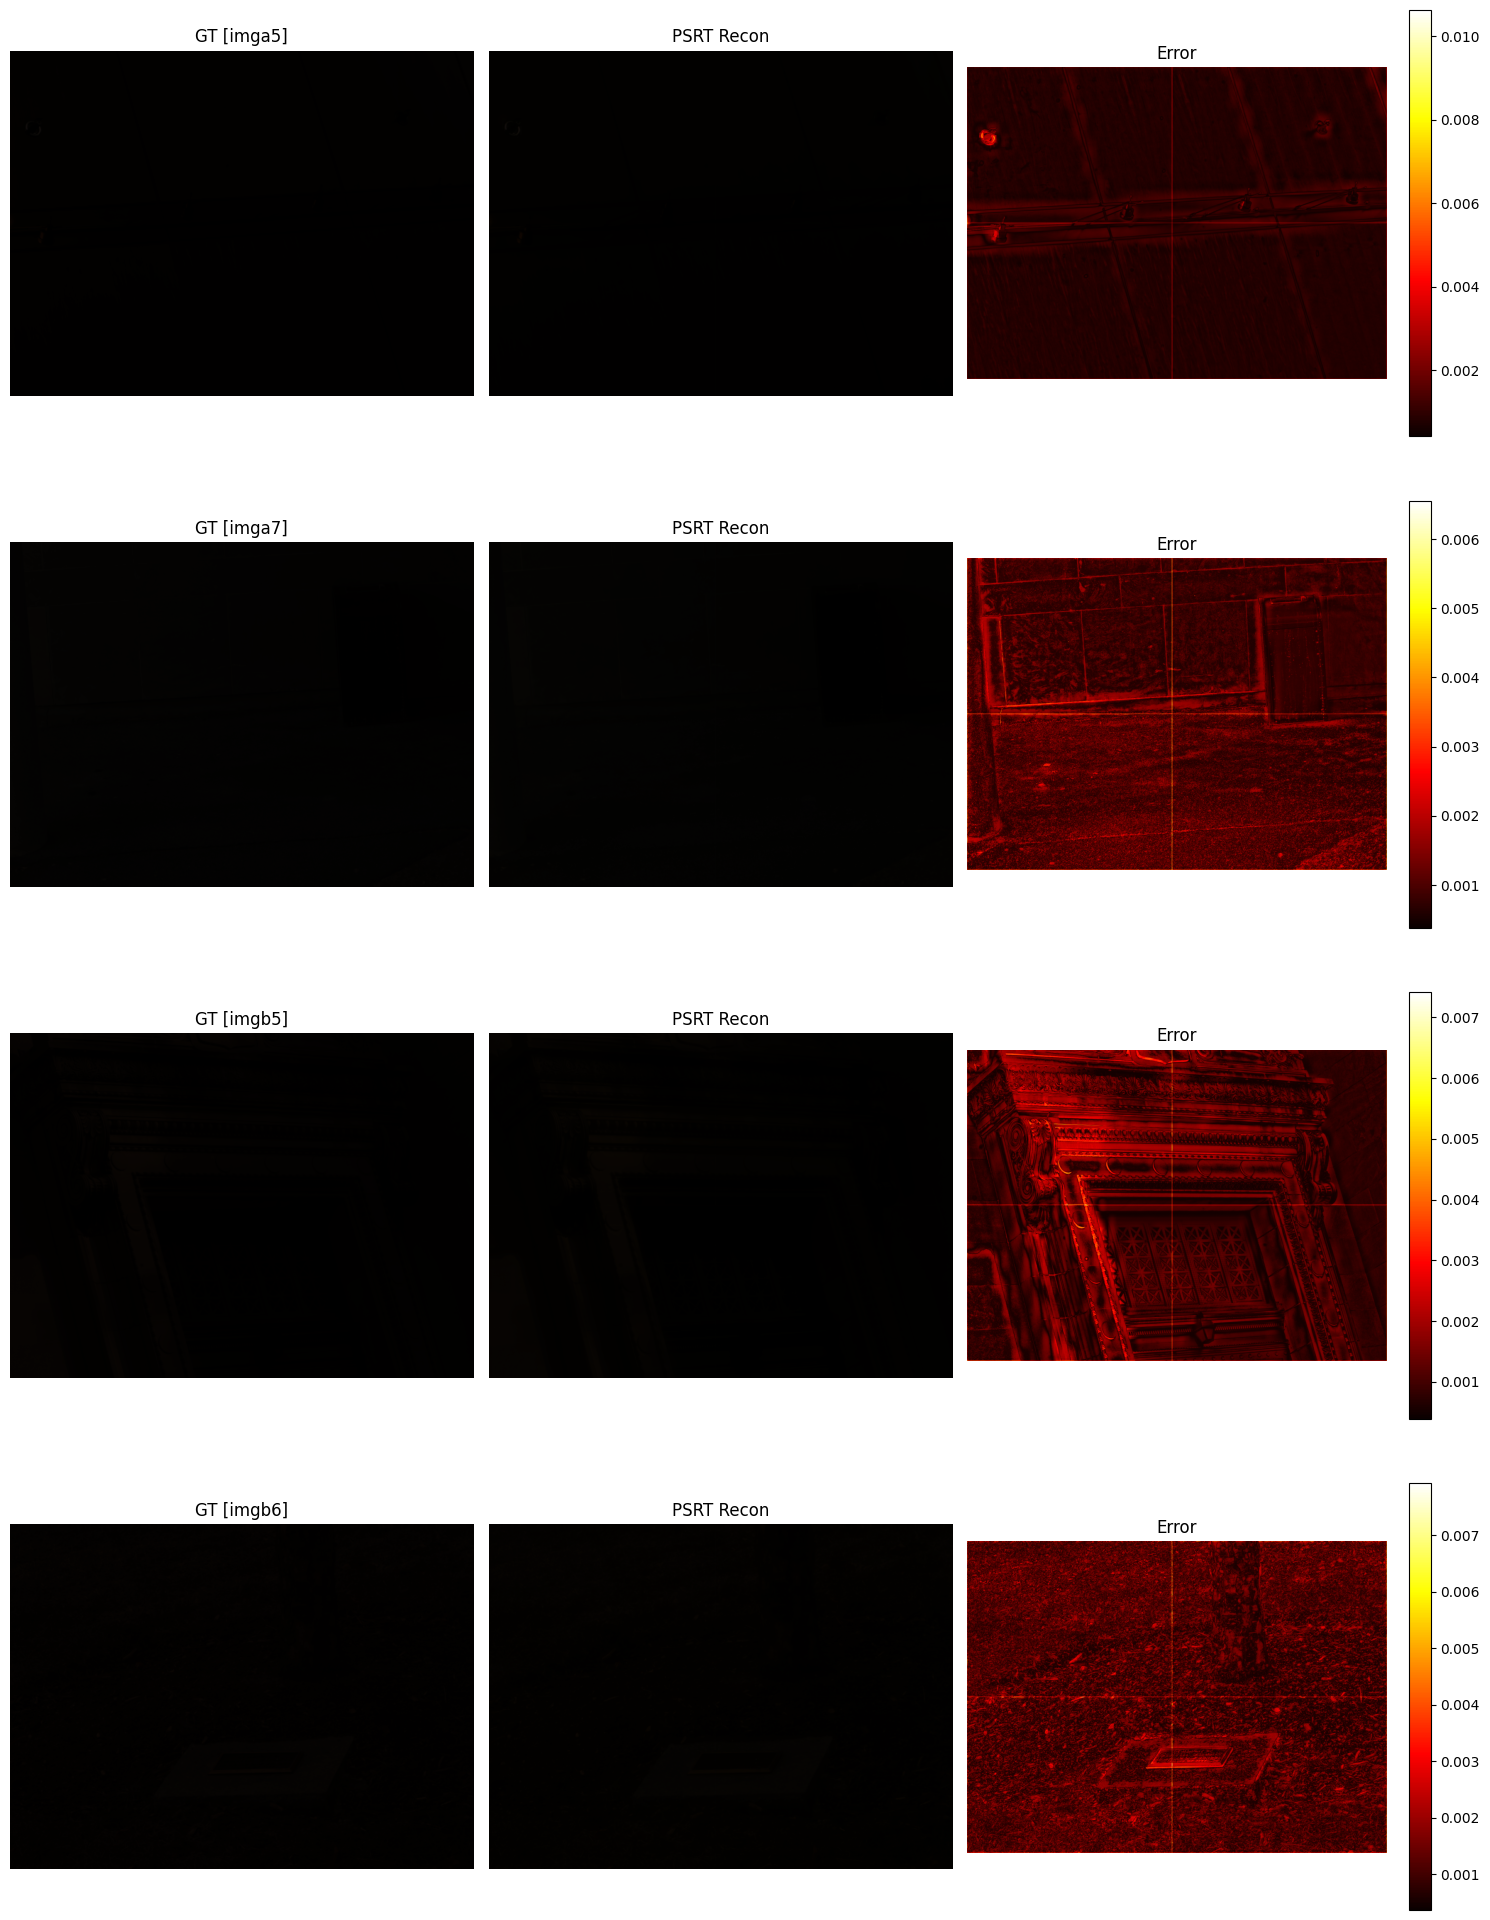

In [20]:
def to_rgb(h): return np.clip(h @ SRF, 0, 1)
n = min(4, len(results))
fig, ax = plt.subplots(n, 3, figsize=(15, 5*n))
if n == 1: ax = ax[np.newaxis, :]
for i in range(n):
    r = results[i]
    ax[i,0].imshow(to_rgb(r['gt']));   ax[i,0].set_title(f'GT [{r["name"]}]'); ax[i,0].axis('off')
    ax[i,1].imshow(to_rgb(r['pred'])); ax[i,1].set_title('PSRT Recon');        ax[i,1].axis('off')
    im = ax[i,2].imshow(np.abs(r['gt']-r['pred']).mean(-1), cmap='hot')
    ax[i,2].set_title('Error'); ax[i,2].axis('off')
    plt.colorbar(im, ax=ax[i,2], fraction=0.046)
plt.tight_layout(); plt.savefig('/kaggle/working/psrt_harvard_vis.png', dpi=150); plt.show()

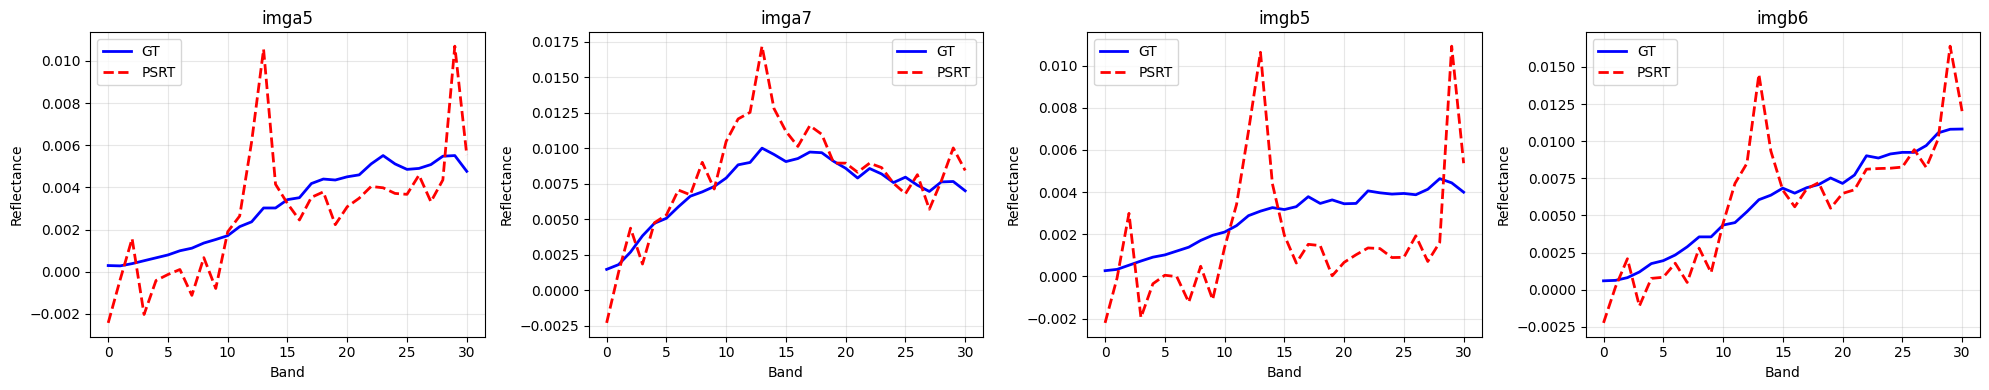

In [21]:
# Spectral profile comparison
n = min(4, len(results))
fig, ax = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1: ax = [ax]
for i in range(n):
    r = results[i]; H,W = r['gt'].shape[:2]; cy,cx = H//2, W//2
    ax[i].plot(r['gt'][cy,cx,:], 'b-', label='GT', lw=2)
    ax[i].plot(r['pred'][cy,cx,:], 'r--', label='PSRT', lw=2)
    ax[i].set_title(r['name']); ax[i].legend(); ax[i].grid(alpha=0.3)
    ax[i].set_xlabel('Band'); ax[i].set_ylabel('Reflectance')
plt.tight_layout(); plt.show()